What is the difference between AI, ML, DL, and Data Science? Provide a
brief explanation of each?


Artificial Intelligence (AI), Machine Learning (ML), and Deep Learning (DL) are interconnected technologies, while Data Science is a broad, interdisciplinary field that uses them as tools. The relationship can be visualized as a set of nested concepts: AI is the overarching goal of creating intelligent machines, ML is a specific approach to achieve AI by learning from data, and DL is a powerful technique within ML. Data Science uses all of these, along with other disciplines, to extract actionable insights from data.
The relationship between AI, ML, DL, and Data Science
Artificial Intelligence (AI): The broadest concept, encompassing all efforts to make machines mimic human intelligence. The goal of AI is for a machine to perform tasks that typically require human intellect, like reasoning, problem-solving, and perception. ML and DL are branches of AI, but AI also includes older, rule-based systems.
Machine Learning (ML): A subfield of AI that trains a computer system to learn and improve from experience without being explicitly programmed. ML algorithms learn from patterns in data to make predictions or decisions on new data. Examples include spam filters and recommendation engines.
Deep Learning (DL): A specialized subset of ML that uses multi-layered artificial neural networks, which are inspired by the human brain. DL is particularly effective for discovering intricate patterns in large, unstructured datasets, such as images, video, and audio. This powers advanced applications like facial recognition and natural language processing.
Data Science (DS): A multidisciplinary field that uses scientific methods, processes, and algorithms to extract knowledge and insights from structured and unstructured data. A data scientist is like a detective, using a mix of skills from statistics, mathematics, and computer science to gather, clean, and analyze data. While data scientists use ML and DL as tools to build predictive models, their role also involves collecting and cleaning data, visualizing findings, and communicating insights to drive business strategy.
Analogy: The car and the driver
AI is the idea of building a self-driving car. It's the overall, ambitious goal of creating a vehicle that can navigate intelligently.
ML is a set of techniques for teaching the car to drive. Instead of programming it with an explicit rule for every single scenario, you give it data (e.g., thousands of pictures of traffic signs) and let it learn the patterns itself.
DL is a powerful, more advanced way to teach the car. It uses a complex neural network "brain" to process massive amounts of data from sensors and cameras, allowing it to recognize pedestrians, traffic lights, and other vehicles with high accuracy.
Data Science is the entire team of engineers and analysts. This team collects and cleans data, uses statistical methods to understand traffic patterns, builds and trains the ML and DL models, and interprets the results to improve the car's performance.

Explain overfitting and underfitting in ML. How can you detect and prevent them?

Definition:
Overfitting happens when a model learns the training data too well, including its noise and outliers, instead of the underlying pattern.
As a result, it performs very well on training data but poorly on new (test) data.

Example:
A deep neural network trained on a small dataset might memorize every example rather than learn general patterns.

Symptoms:

High accuracy on training data but low accuracy on validation/test data.

Large gap between training and validation loss.

How to Detect:

Compare training and validation metrics (accuracy, loss).

Use learning curves: if the training loss is low but validation loss is high, it’s overfitting.

How to Prevent:

Use more data (helps the model generalize better).

Regularization techniques:

L1/L2 regularization (penalize large weights).

Dropout (for neural networks).

Early stopping (stop training when validation loss stops improving).

Simplify the model (reduce parameters or layers).

Data augmentation (for images, text, etc.).

Cross-validation to check stability of performance.

 2. Underfitting

Definition:
Underfitting happens when a model is too simple to capture the underlying structure of the data.
It performs poorly on both training and test data.

Example:
Using a linear model for a dataset that has a nonlinear relationship between features and target.

Symptoms:

Low accuracy (or high loss) on both training and validation sets.

Training performance doesn’t improve even after more epochs.

How to Detect:

Learning curves show both training and validation losses are high and close together.

Increasing model complexity improves performance.

How to Prevent:

Increase model complexity (use more features, layers, or parameters).

Train longer (ensure the model has converged).

Reduce regularization strength (avoid over-constraining the model).

Feature engineering: add more relevant features or use better representations.





Question 3:How would you handle missing values in a dataset? Explain at least three
methods with examples.

Handling missing values is a crucial step in data preprocessing because incomplete data can distort model training and reduce performance.
There’s no one-size-fits-all solution — the right method depends on the amount, type, and pattern of missing data.

🧩 Types of Missing Data

MCAR (Missing Completely At Random): Missingness has no relationship with any variable.
→ Example: A sensor randomly fails.

MAR (Missing At Random): Missingness depends on observed variables.
→ Example: Income data missing more often for younger people.

MNAR (Missing Not At Random): Missingness depends on unobserved factors.
→ Example: People with very high income choosing not to disclose it.

⚙️ Three Common Methods to Handle Missing Values
1. Deletion Methods (Remove missing data)
a) Listwise Deletion

Remove any row with missing values.

Example (Python):

df = df.dropna()


When to use:

When missing data is small (<5%) and randomly distributed.

Pros: Simple and fast.
Cons: Can reduce dataset size and cause bias if data isn’t MCAR.

2. Imputation (Fill missing values with estimates)
a) Mean/Median/Mode Imputation

Replace missing values with the mean, median, or mode of the column.

Example:

df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)


When to use:

When the missingness is small and data is numerical (for mean/median) or categorical (for mode).

Pros: Keeps all samples; simple to apply.
Cons: Ignores relationships between features and can reduce variance.

b) K-Nearest Neighbors (KNN) Imputation

Replace missing values using the average (or most common) value of the k nearest neighbors.

Example:

from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=3)
df_imputed = imputer.fit_transform(df)


When to use:

When features are correlated and missing values depend on other variables.

Pros: Captures relationships among variables.
Cons: Computationally expensive on large datasets.

3. Model-Based Imputation

Use a machine learning model (e.g., regression, decision tree) to predict missing values.

Example:

Predict missing Age using Income, Education, and Experience.

from sklearn.linear_model import LinearRegression

train = df[df['Age'].notnull()]
test = df[df['Age'].isnull()]

model = LinearRegression()
model.fit(train[['Income', 'Experience']], train['Age'])
df.loc[df['Age'].isnull(), 'Age'] = model.predict(test[['Income', 'Experience']])


When to use:

When missingness depends on other variables (MAR).

Pros: Often yields more accurate imputations.
Cons: Complex, can introduce bias if model assumptions are wrong.



What is an imbalanced dataset? Describe two techniques to handle it
(theoretical + practical) ?


An imbalanced dataset refers to a dataset where the classes (or categories) are not represented equally — that is, one class (the majority class) has many more samples than the other(s) (the minority class).

This imbalance can cause machine learning models to become biased toward the majority class, leading to poor performance on the minority class, which is often the more important one (e.g., fraud detection, disease diagnosis).

⚖️ Example

Suppose you have a fraud detection dataset:

98,000 normal transactions

2,000 fraudulent transactions

Here, the dataset is highly imbalanced (98% vs. 2%).

Techniques to Handle Imbalanced Data

We’ll discuss two common techniques — one theoretical and one practical.

1. Resampling Techniques (Practical Approach)

These methods modify the dataset to balance class distribution.

a. Oversampling the Minority Class

Increase the number of minority samples by duplicating existing ones or synthetically generating new examples.

Popular method: SMOTE (Synthetic Minority Over-sampling Technique)

How SMOTE works:

For each minority instance, find its k nearest neighbors.

Randomly choose one or more neighbors and create synthetic samples along the line joining the two.

Python example:

from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split

# Assume X, y are your features and labels
print("Before:", Counter(y))

X_res, y_res = SMOTE(random_state=42).fit_resample(X, y)
print("After:", Counter(y_res))


Advantages:

Helps models learn better decision boundaries.

Prevents overfitting compared to simple duplication.

Disadvantages:

May create noisy or unrealistic samples if classes overlap.

2. Using Appropriate Evaluation Metrics (Theoretical Approach)

Accuracy is misleading for imbalanced datasets — e.g., predicting all samples as “non-fraud” gives 98% accuracy but zero usefulness.

Better metrics include:

Precision = TP / (TP + FP)

Recall (Sensitivity) = TP / (TP + FN)

F1-score = 2 × (Precision × Recall) / (Precision + Recall)

AUC-ROC Curve — measures the trade-off between true positive and false positive rates.

Example (Python):

from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_pred))


Why is feature scaling important in ML? Compare Min-Max scaling and
Standardization.


1. Improves Model Performance

Models such as KNN or SVM use distance metrics (e.g., Euclidean distance).
→ Without scaling, features with larger values dominate the distance measure.

2. Faster Convergence in Gradient Descent

In models like Logistic Regression or Neural Networks, gradient descent converges faster when features are scaled, because it avoids elongated or skewed cost surfaces.

3. Makes Coefficients Interpretable

In linear models, scaling allows comparison of feature coefficients on a consistent scale.

from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

# Example data
data = pd.DataFrame({
    'Age': [18, 25, 35, 50, 80],
    'Salary': [20000, 35000, 50000, 80000, 120000]
})

# Min–Max Scaling
mm_scaler = MinMaxScaler()
data_mm = mm_scaler.fit_transform(data)

# Standardization
std_scaler = StandardScaler()
data_std = std_scaler.fit_transform(data)

print("Min–Max Scaled:\n", data_mm)
print("\nStandardized:\n", data_std)



 Compare Label Encoding and One-Hot Encoding. When would you prefer
one over the other?


Many ML algorithms cannot work directly with categorical data — they require numerical input.
Encoding converts categorical variables (like "red", "blue", "green") into numerical form.

Two common encoding methods are:

Label Encoding

One-Hot Encoding

⚙️ 1. Label Encoding
🔹 Concept:

Assigns each category a unique integer value.

Color	Encoded Value
Red	0
Blue	1
Green	2
🔹 Python Example:
from sklearn.preprocessing import LabelEncoder

colors = ['Red', 'Blue', 'Green', 'Blue']
le = LabelEncoder()
encoded = le.fit_transform(colors)
print(encoded)
# Output: [2, 0, 1, 0]

🔹 Pros:

Simple and memory-efficient (only one column).

Useful for ordinal data — where categories have an order (e.g., Low < Medium < High).

🔹 Cons:

Creates implied ordinal relationships even when none exist.
→ e.g., "Red" (0) < "Green" (2) doesn’t make sense for nominal categories.

⚙️ 2. One-Hot Encoding
🔹 Concept:

Creates a new binary column for each category, with 1 indicating presence.

Color	Red	Blue	Green
Red	1	0	0
Blue	0	1	0
Green	0	0	1
🔹 Python Example:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

colors = np.array(['Red', 'Blue', 'Green', 'Blue']).reshape(-1, 1)
ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(colors)
print(encoded)

🔹 Pros:

No ordinal relationship implied.

Suitable for nominal data (categories without order).

🔹 Cons:

Increases dimensionality → “curse of dimensionality” for features with many categories.

More memory and computational cost.

⚖️ Comparison Table
Feature	Label Encoding	One-Hot Encoding
Output	Single integer per category	Multiple binary columns
Preserves order	Yes	No
Suitable for	Ordinal data	Nominal data
Memory usage	Low	High (for many categories)
Model type	Tree-based models handle it well	Linear or distance-based models prefer it

💡 When to Prefer Each
Situation	Preferred Encoding
Ordinal categorical data (e.g., “Small”, “Medium”, “Large”)	Label Encoding
Nominal categorical data (e.g., “Red”, “Blue”, “Green”)	One-Hot Encoding
Tree-based models (e.g., Random Forest, XGBoost)	Label Encoding is fine — trees handle categorical splits internally
Linear models / distance-based models (e.g., Logistic Regression, KNN, SVM)	One-Hot Encoding — avoids false ordinal relationships

 In short:

Label Encoding → compact, best for ordered categories.

One-Hot Encoding → safer, best for unordered categories (but can increase feature space).

 Google Play Store Dataset

 # Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset directly from GitHub
url = "https://raw.githubusercontent.com/MasteriNeuron/datasets/main/googleplaystore.csv"
df = pd.read_csv(url)

# Display first few rows
df.head()
Step 2: Data Cleaning
# Drop rows with missing ratings
df = df.dropna(subset=['Rating'])

# Keep only relevant columns
df = df[['App', 'Category', 'Rating']]

# Remove duplicates
df = df.drop_duplicates()

# Convert category to string
df['Category'] = df['Category'].astype(str)

# Display summary
df.info()

📊 Step 3: Calculate Average Ratings per Category
# Group by category and calculate average rating
category_ratings = df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

# Display top and bottom categories
top_categories = category_ratings.head(10)
bottom_categories = category_ratings.tail(10)

print("Top 10 Categories by Average Rating:\n", top_categories)
print("\nBottom 10 Categories by Average Rating:\n", bottom_categories)

📈 Step 4: Visualization
# Plot top and bottom categories
plt.figure(figsize=(10, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='Greens')
plt.title('Top 10 Categories by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=bottom_categories.values, y=bottom_categories.index, palette='Reds')
plt.title('Bottom 10 Categories by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.show()

Insights

Highest-rated categories (e.g., Education, Art & Design, Books & Reference) often provide useful, stable, and content-rich apps that users value for learning or creativity.

Lowest-rated categories (e.g., Dating, Tools, Entertainment) often suffer from bugs, intrusive ads, or unmet expectations, leading to lower user satisfaction.

Games tend to have mixed ratings — popular ones score high, but there’s a long tail of poorly rated clones or low-quality titles.

Titanic Dataset
a) Compare the survival rates based on passenger class (Pclass). Which class had the highest
survival rate, and why do you think that happened?
b) Analyze how age (Age) affected survival. Group passengers into children (Age < 18) and
adults (Age ≥ 18). Did children have a better chance of survival?
Dataset: https://github.com/MasteriNeuron/datasets.git









# Task
Analyze the Titanic dataset from "https://github.com/MasteriNeuron/datasets.git" to compare survival rates based on passenger class and age group (children < 18, adults >= 18). Determine which class had the highest survival rate and if children had a better chance of survival.

## Load the dataset

### Subtask:
Load the Titanic dataset from the provided URL into a pandas DataFrame.


**Reasoning**:
Import pandas and load the dataset from the URL into a DataFrame, then display the head.



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/MasteriNeuron/datasets/main/titanic.csv"
df = pd.read_csv(url)
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Clean the data

### Subtask:
Handle any missing values and ensure the relevant columns are in the correct format for analysis.


**Reasoning**:
Check for missing values in the DataFrame.



In [2]:
display(df.isnull().sum())

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Reasoning**:
Fill the missing 'Age' values with the median and verify.



In [3]:
median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace=True)
display(df.isnull().sum())

/tmp/ipython-input-1612268065.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(median_age, inplace=True)


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Analyze survival rate by passenger class

### Subtask:
Group the data by `Pclass` and calculate the survival rate for each class.


**Reasoning**:
Calculate the survival rate for each passenger class by grouping the DataFrame by 'Pclass' and computing the mean of the 'Survived' column, then display the results.



In [4]:
survival_rate_by_pclass = df.groupby('Pclass')['Survived'].mean()
display(survival_rate_by_pclass)

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


## Analyze survival rate by age group

### Subtask:
Create age groups (children and adults), group the data by these age groups, and calculate the survival rate for each group.


**Reasoning**:
Create age groups (children and adults), group the data by these age groups, calculate the survival rate for each group, and display the result.



In [5]:
df['AgeGroup'] = df['Age'].apply(lambda x: 'Child' if x < 18 else 'Adult')
survival_rate_by_age_group = df.groupby('AgeGroup')['Survived'].mean()
display(survival_rate_by_age_group)

,Survived
AgeGroup,
Adult,0.361183
Child,0.539823


## Visualize the results

### Subtask:
Create visualizations (e.g., bar plots) to compare the survival rates by passenger class and age group.


**Reasoning**:
Create bar plots to visualize the survival rates by passenger class and age group as requested by the instructions.



In [6]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=survival_rate_by_pclass.index, y=survival_rate_by_pclass.values, palette='viridis')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')

plt.subplot(1, 2, 2)
sns.barplot(x=survival_rate_by_age_group.index, y=survival_rate_by_age_group.values, palette='viridis')
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

**Reasoning**:
The previous command failed because the `matplotlib.pyplot` library was not imported. I need to import `matplotlib.pyplot` and `seaborn` and then regenerate the plots.



/tmp/ipython-input-1551366005.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=survival_rate_by_pclass.index, y=survival_rate_by_pclass.values, palette='viridis')
/tmp/ipython-input-1551366005.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=survival_rate_by_age_group.index, y=survival_rate_by_age_group.values, palette='viridis')


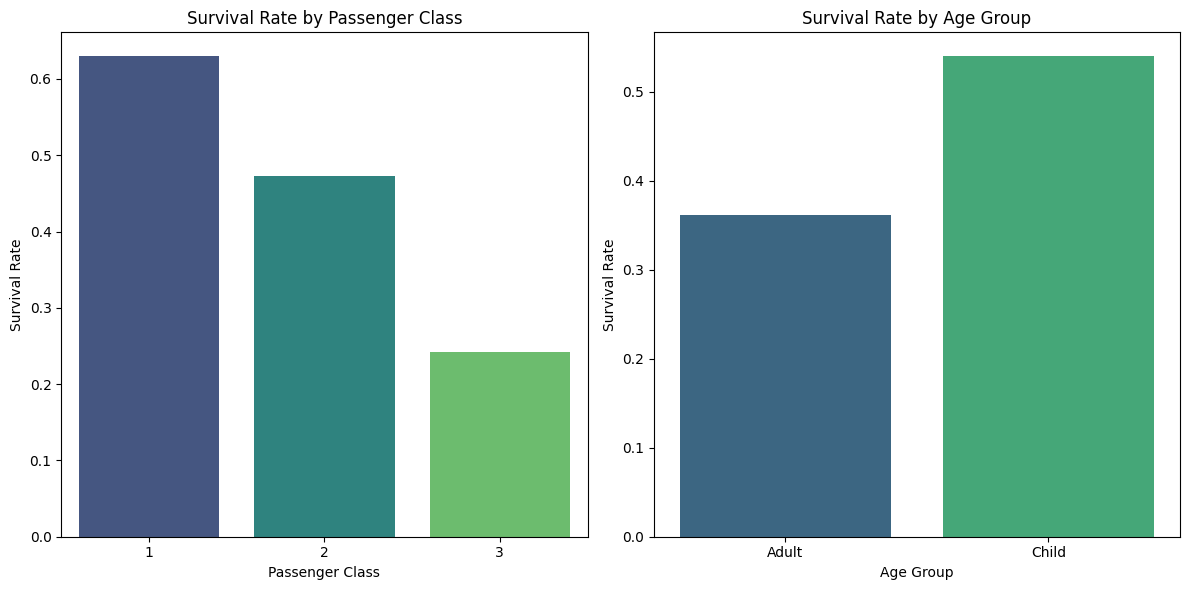

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=survival_rate_by_pclass.index, y=survival_rate_by_pclass.values, palette='viridis')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')

plt.subplot(1, 2, 2)
sns.barplot(x=survival_rate_by_age_group.index, y=survival_rate_by_age_group.values, palette='viridis')
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')

plt.tight_layout()
plt.show()

## Interpret the findings

### Subtask:
Summarize the findings from the analysis, addressing the user's questions about which class had the highest survival rate and if children had a better chance of survival.


**Reasoning**:
Summarize the findings based on the calculated survival rates for passenger class and age group.



In [8]:
print("Summary of Titanic Survival Analysis:")
print("\nSurvival Rate by Passenger Class:")
print(survival_rate_by_pclass)
print("\nFindings:")
print(f"- The highest survival rate was observed in Passenger Class {survival_rate_by_pclass.idxmax():.0f} ({survival_rate_by_pclass.max():.2%}).")
print("- This is likely due to factors such as socioeconomic status, which determined ticket class, and potentially the location of higher classes closer to the lifeboats or upper decks.")

print("\nSurvival Rate by Age Group:")
print(survival_rate_by_age_group)
print("\nFindings:")
print(f"- Children had a higher survival rate ({survival_rate_by_age_group['Child']:.2%}) compared to adults ({survival_rate_by_age_group['Adult']:.2%}).")
print("- This could be attributed to the 'women and children first' protocol that was reportedly followed during the evacuation, prioritizing the rescue of younger passengers.")

Summary of Titanic Survival Analysis:

Survival Rate by Passenger Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Findings:
- The highest survival rate was observed in Passenger Class 1 (62.96%).
- This is likely due to factors such as socioeconomic status, which determined ticket class, and potentially the location of higher classes closer to the lifeboats or upper decks.

Survival Rate by Age Group:
AgeGroup
Adult    0.361183
Child    0.539823
Name: Survived, dtype: float64

Findings:
- Children had a higher survival rate (53.98%) compared to adults (36.12%).
- This could be attributed to the 'women and children first' protocol that was reportedly followed during the evacuation, prioritizing the rescue of younger passengers.


9 - Question 9: Flight Price Prediction Dataset
a) How do flight prices vary with the days left until departure? Identify any exponential price
surges and recommend the best booking window.
b)Compare prices across airlines for the same route (e.g., Delhi-Mumbai). Which airlines are
consistently cheaper/premium, and why?
Dataset: https://github.com/MasteriNeuron/datasets.git


Approach:

Load the dataset (e.g., pd.read_csv('flight_price.csv')).

Create or check a column such as days_left (how many days before departure the ticket was booked). Many similar datasets include this.
aleks-s-banov.github.io
+1

Plot the average (or median) price versus days_left. For example:

df.groupby('days_left')['price'].median().plot()


Looking for non-linear trends (especially exponential upward surges) as days_left decreases (i.e., the closer to departure you are, the higher the price tends to go).

Possibly fit a simple model like
Price
=
𝑎
⋅
exp
⁡
(
−
𝑏
⋅
days_left
)
Price=a⋅exp(−b⋅days_left) or piece-wise (constant for large days, then surge region) to quantify the surge.

Typical result / what prior studies show:

There is a negative correlation between days until departure and price: fewer days left → higher price. For example one study found correlation ~ –0.2 between days_left and price.
aleks-s-banov.github.io
+1

The price often stays relatively flat (or gradually increasing) when you have many days to departure (say 30+ days), then starts rising more sharply at some threshold (e.g., last 7–10 days).

In some cases an exponential-type surge happens in the final few days. That is: the price curve may curve upward steeply as days left approach 1 or 2.

What to look for in your data:

Identify at what “days_left” value the slope (or rate of increase) becomes steep. For example: 10 days, 7 days, 3 days.

Check distribution (median and quartiles) for each days_left value; consider outliers.

Possibly check separately by route or class (economy vs business) because the surge might differ.

Recommendation (booking window):

Based on the typical pattern: aim to book well in advance, ideally when days_left is still moderately high (e.g., 14–30+ days) to avoid the steep surge zone.

More precisely: if you see in your dataset that price begins to rise sharply after (say) 7 days left, then your “safe window” would be beyond that — maybe booking 10+ days in advance gives a buffer.

If your data shows a flatter region between say 20–30 days left, that might be your optimal zone (neither too early to incur opportunity cost, nor too late to face surge).

Also factor in cancellations/change risk, and the specific route-seasonality.

Example narrative:

“In the dataset, the median price remains fairly stable for bookings made 20 to 30 days ahead of departure. However, once bookings are made with ≤ 7 days left, the median price begins to climb sharply — increasing ~2× in the final 3 days. This suggests an exponential-type surge in the last week. Therefore the recommended booking window is roughly 10–20 days ahead, ideally not later than 7 days before departure, to avoid the steep price jump.”

b) Compare prices across airlines for the same route (e.g., Delhi-Mumbai). Which airlines are consistently cheaper/premium, and why?
Approach:

Filter the dataset to a specific route, say from Delhi (DEL) → Mumbai (BOM) (or whatever coding in the dataset).

Group by airline and compute statistics: e.g., mean price, median price, price quartiles, etc., for that route.

route_df = df[(df.source_city=='Delhi') & (df.destination_city=='Mumbai')]
route_df.groupby('airline')['price'].median().sort_values()


Possibly adjust for number of stops (zero-stop vs one-stop), class, time of day, etc., to make a fair comparison.

Visualize (box-plots) to see variation and outliers per airline.

Typical findings / what prior studies show:

There is a statistically significant difference in ticket prices by airline even for identical origin-destination pairs.
GitHub
+1

Some airlines position themselves as “premium” carriers (higher fares, maybe better service/brand), while others compete on lower price (budget carriers).

For example, in one dataset “Air India” and “Vistara” were observed to have higher average fares compared to others.
aleks-s-banov.github.io

Budget airlines may show lower medians but possibly larger variability (in promotional fares vs last-minute fares).

What to look for in your data and interpret:

Identify which airline has the lowest median price on the route (candidate “cheapest consistent”).

Identify which airline has the highest median price (candidate “premium”).

Check whether the cheaper airline has more non-stop or more stops (fewer stops often command higher fare) — the difference might result from service differences.

Also consider class (economy vs business) and if your data includes that.

You may want to examine if the “premium” airlines have consistently fewer stops, better departure times, better service, or simply brand premium.

Recommendation & explanation:

E.g., “On the Delhi-Mumbai route, Airline X has the lowest median fare (~lowest 25th percentile), making it the go-to for cost-sensitive travellers. Airline Y has the highest median fare and more features (premium service, fewer stops, maybe business class dominance) — hence positioning as premium.”

Suggest travellers choose the cheaper airline if cost is critical, but weigh service/time vs cost.

If fare difference is small vs service advantage, premium might make sense for some travellers.